In [12]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [25]:
df_original = pd.read_stata('Mexico-2023-full-data.dta')

In [26]:
#limpiamos los datos

#columnas importantes
cols = {'d2': 'sales', 'l1': 'employees', 'l10': 'training', 'k82': 'financing'}
df_clean = df_original[list(cols.keys())].copy().rename(columns=cols)

df_clean['sales'] = pd.to_numeric(df_clean['sales'], errors='coerce')

df_clean['training'] = df_clean['training'].map({'Yes': 'Con Capacitación', 'No': 'Sin Capacitación'})
df_clean['financing'] = df_clean['financing'].map({
    'Yes, both a line of credit and a loan': 'Con Financiamiento',
    'Yes, a loan only': 'Con Financiamiento',
    'Yes, a line of credit only': 'Con Financiamiento',
    'No': 'Sin Financiamiento'
})
promedio = df_clean['sales'].mean()
df_clean['successful'] = np.where(df_clean['sales'] > promedio, 'Éxito', 'Fracaso')
df_bayes = df_clean.dropna().copy()

In [27]:
#agrupamos las empresas de la misma combinación 
analisis_frecuencias = df_bayes.groupby(['financing', 'training', 'successful']).size().unstack(fill_value=0)

/var/folders/5n/yw6j7s2n0d75d_bx5pnw2bkr0000gn/T/ipykernel_25645/640454833.py:2: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  analisis_frecuencias = df_bayes.groupby(['financing', 'training', 'successful']).size().unstack(fill_value=0)


In [28]:
#calculamos la probabilidad
prob_tabla = analisis_frecuencias.div(analisis_frecuencias.sum(axis=1), axis=0)

In [29]:
prob_reporte = prob_tabla.reset_index()
prob_reporte['Etiqueta'] = (
    prob_reporte['financing'].astype(str) + ' y ' + 
    prob_reporte['training'].astype(str)
)
print("Tabla de Probabilidades Condicionales:")
print(prob_reporte[['Etiqueta', 'Éxito']])

Tabla de Probabilidades Condicionales:
successful                               Etiqueta     Éxito
0           Con Financiamiento y Con Capacitación  0.486631
1           Con Financiamiento y Sin Capacitación  0.212987
2           Sin Financiamiento y Con Capacitación  0.218182
3           Sin Financiamiento y Sin Capacitación  0.079545


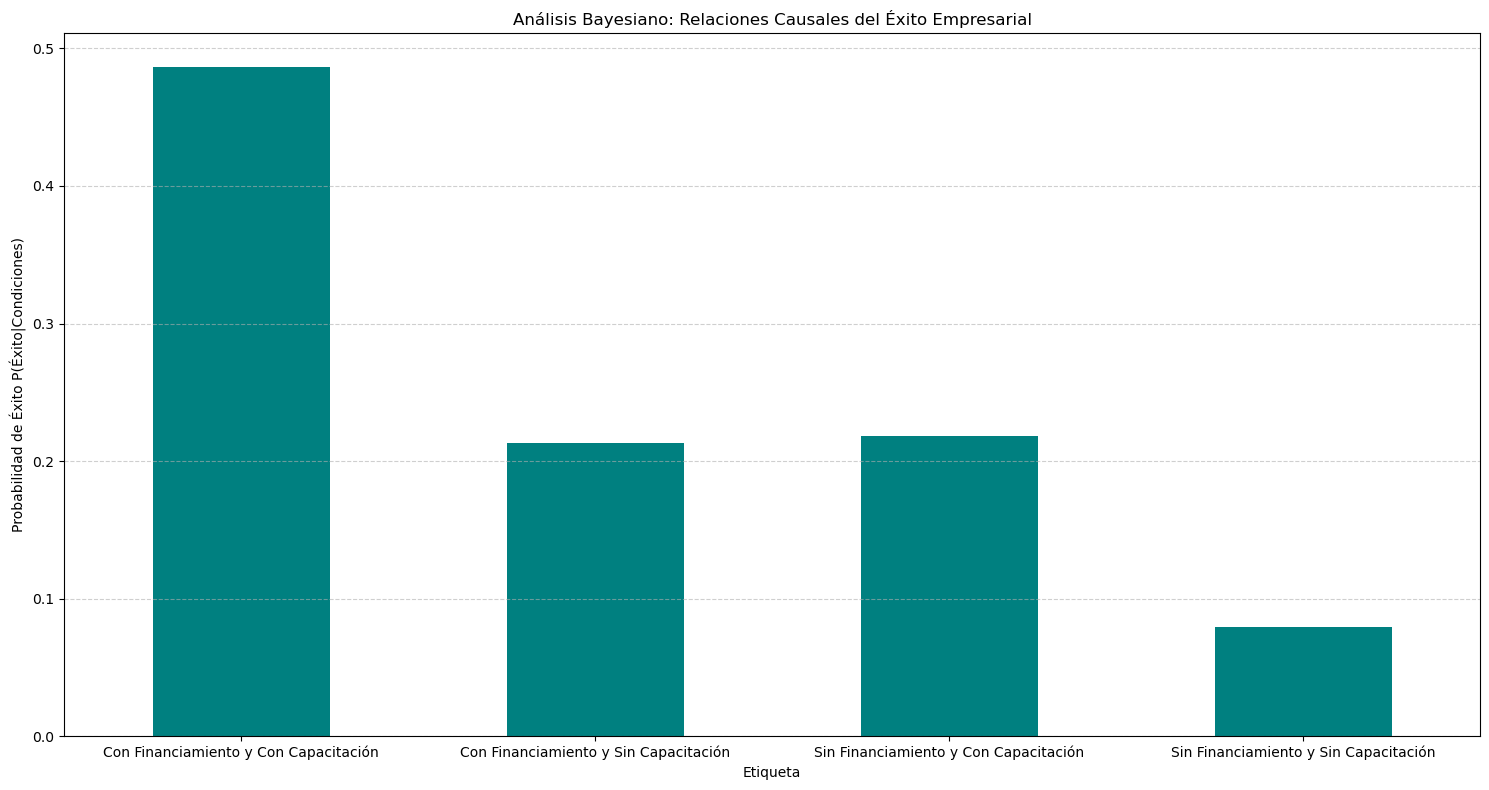

In [31]:
#grafica
fig, ax = plt.subplots(figsize=(15, 8))
prob_reporte.plot(kind='bar', x='Etiqueta', y='Éxito', ax=ax, color='teal', legend=False)

ax.set_ylabel('Probabilidad de Éxito P(Éxito|Condiciones)')
ax.set_title('Análisis Bayesiano: Relaciones Causales del Éxito Empresarial')
plt.xticks(rotation=0)
plt.grid(axis='y', linestyle='--', alpha=0.6)

plt.tight_layout()
plt.show()

## Conclusiones ##

**¿Qué relaciones causales existen entre financiamiento, capacitación y éxito empresarial?**

Se observa que el financiamiento y la capacitación influyen directamente en el éxito empresarial. Las empresas que cuentan con ambas condiciones tienen la mayor probabilidad de éxito, mientras que aquellas que no tienen ni financiamiento ni capacitación apenas alcanzan un 7%. 
Esto demuestra que el acceso a recursos financieros y la formación del capital humano son factores complementarios clave para mejorar el desempeño empresarial.

## CONCLUSIÓN FINAL EN EL ACHIVO "CONCLUSION.md" ##